--- Starting Analysis_4 (RunID: 20251130_153500) ---
Loading OnlyMat Features...
Common Samples: 1046
Processing linear_top3 - silhouette ...
Processing linear_top3 - dunn ...
Processing linear_top3 - gap ...
Processing linear_top3 - ch ...
Processing linear_top3 - db ...
Processing linear_top3 - ptbiserial ...
Processing linear_cumeig - silhouette ...
Processing linear_cumeig - dunn ...
Processing linear_cumeig - gap ...
Processing linear_cumeig - ch ...
Processing linear_cumeig - db ...
Processing linear_cumeig - ptbiserial ...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[SAVE] Summary Table: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/paper_4.2.4.4_OHFP/Analysis_4/bidirectional_summary/Table_Summary_Composition6_Analysis_4.csv


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

[SAVE] Fig C


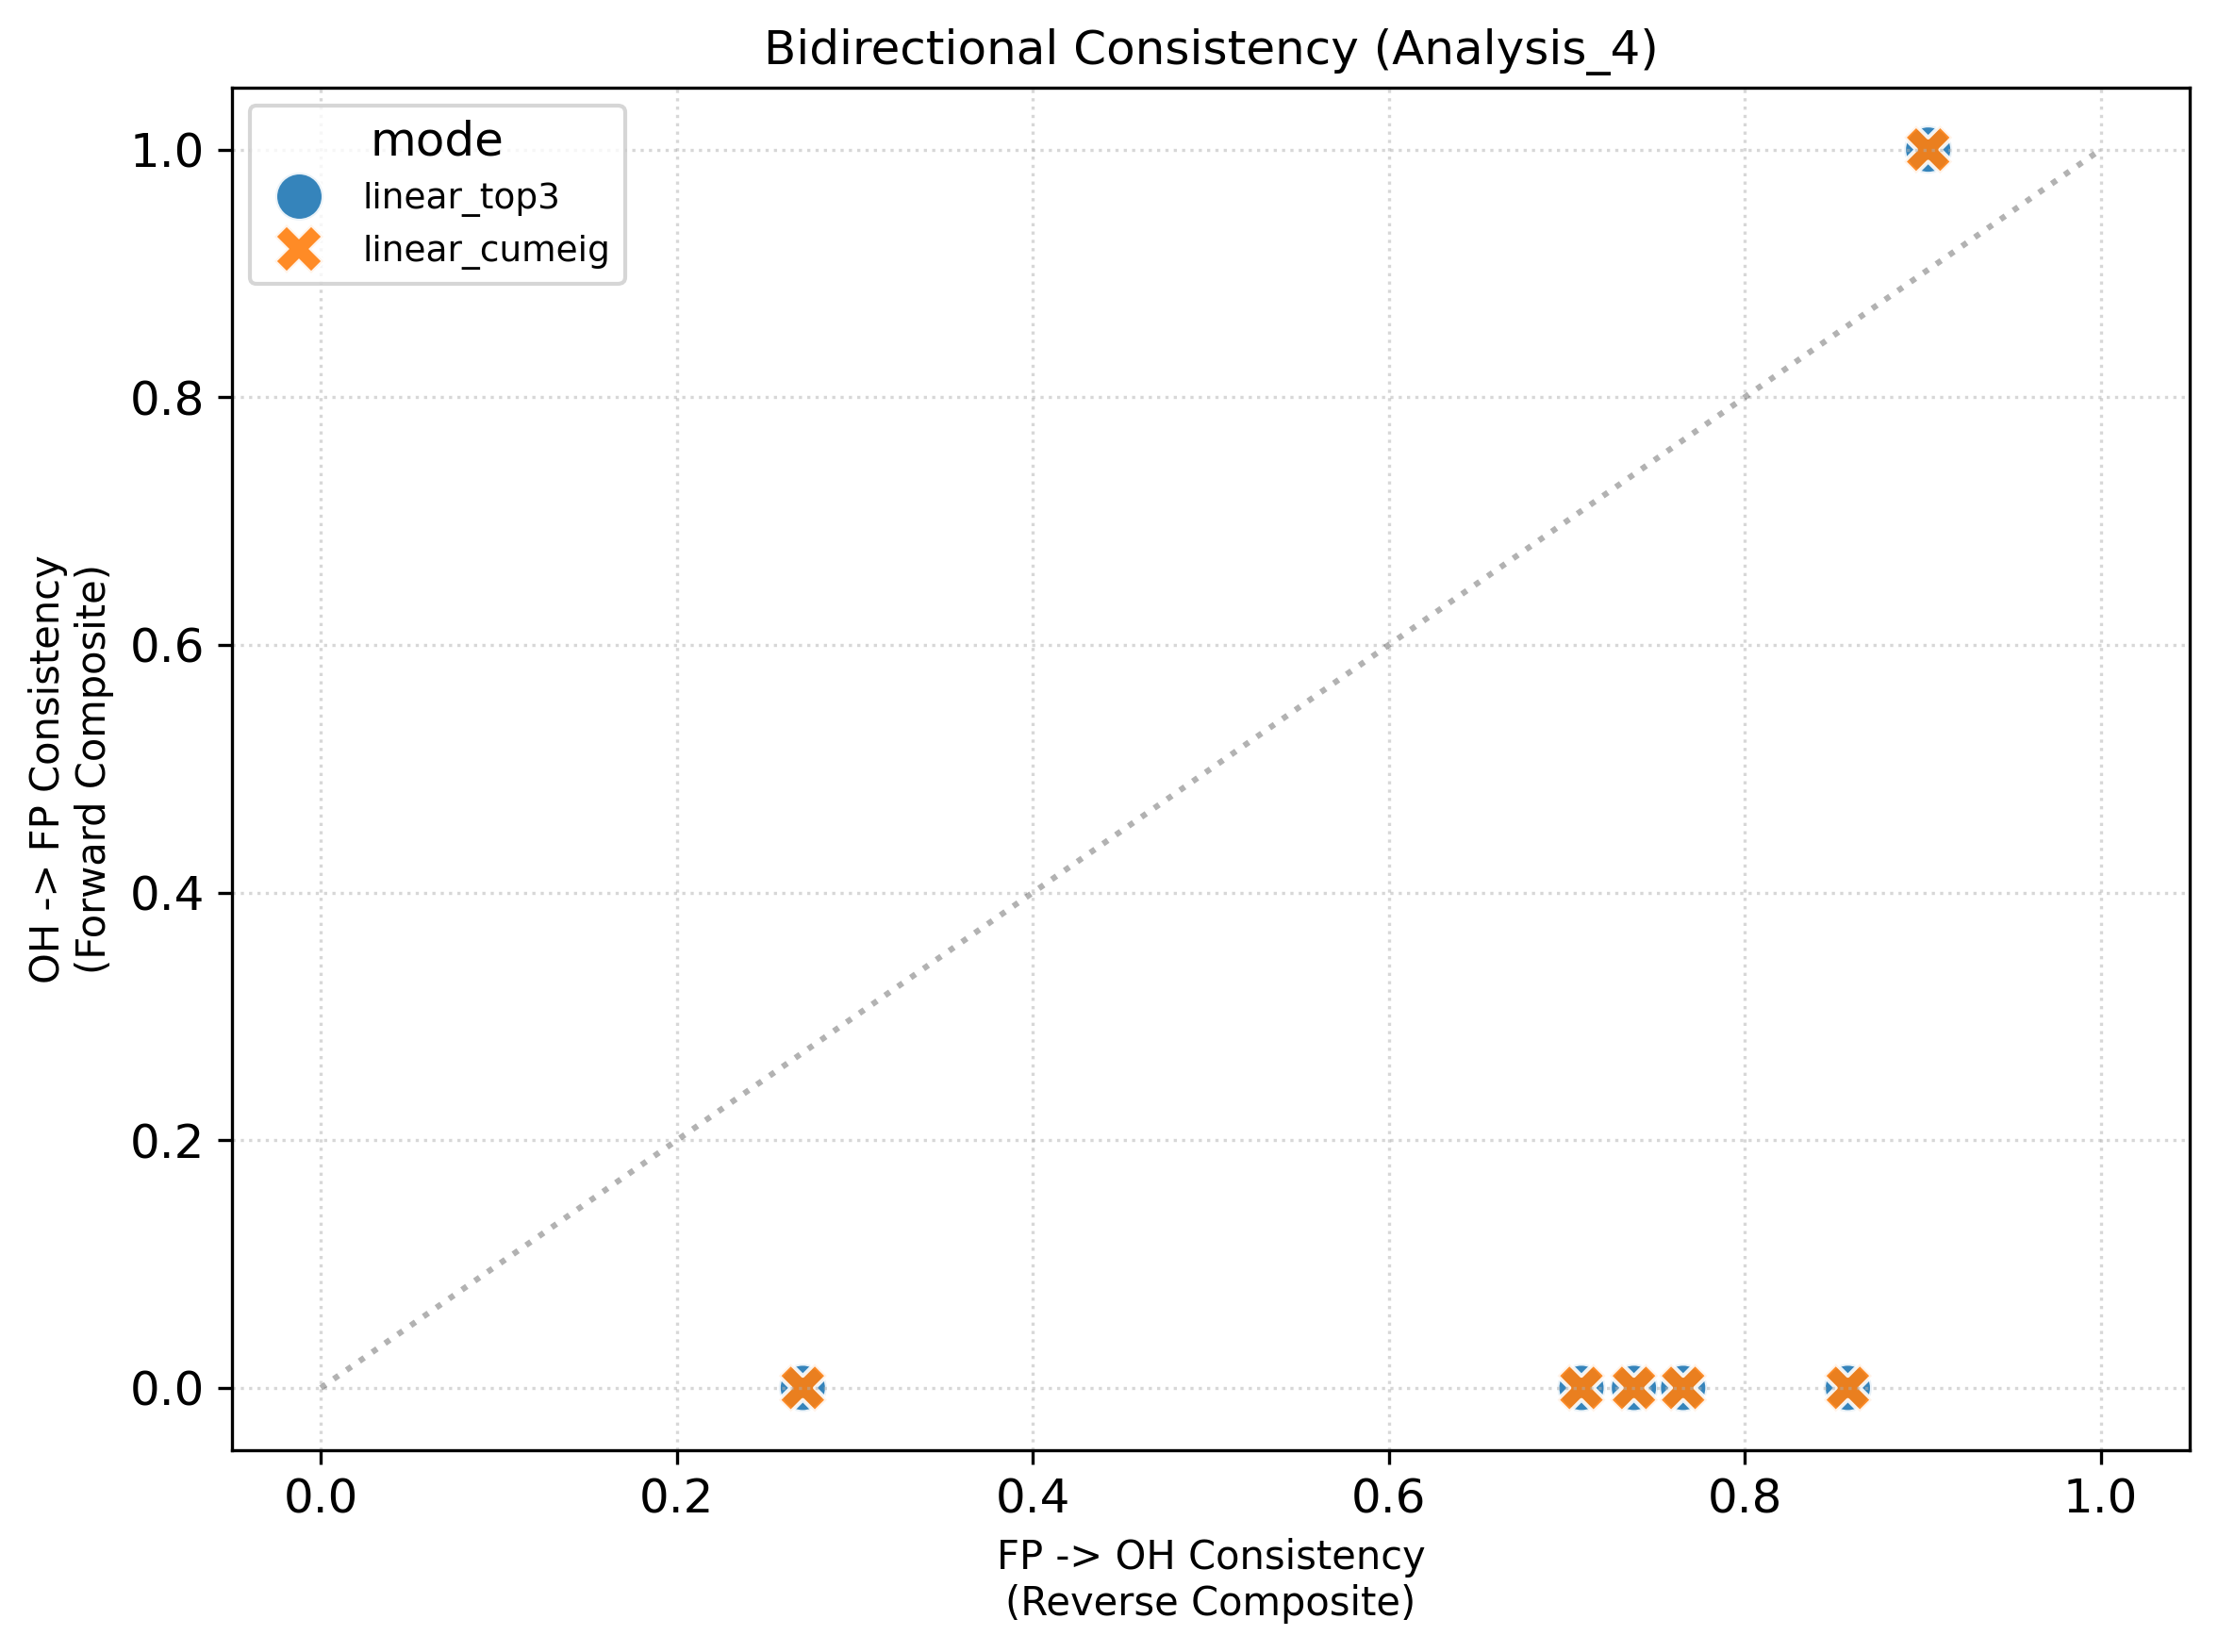

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
STEP4_2_4_4_composition6_analysis.py
------------------------------------
目的: 4.2.4.4節の解析 (双方向 Composition6)。
      実データ(features_onlyMat)を用いて、材料(OH)と構造(FP)の共起関係を定量化する。
      
      Analysis 3 (OnlyMat Cluster) と Analysis 4 (AllVar Cluster) の
      両方に対応可能な汎用設計。
"""

from __future__ import annotations
from pathlib import Path
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon, cosine
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations

# ==========================================
# 1. 設定 (User Configuration)
# ==========================================
RUN_ID = "20251130_153500"
ROOT = Path("/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127")

# ★ 解析モード設定 ★
# "Analysis_3": 材料変数のみでクラスタリングした結果を使う場合
# "Analysis_4": 全変数でクラスタリングした結果を使う場合 (現在のRUN_IDはこちらと想定)
ANALYSIS_MODE = "Analysis_4" 

# 入力ディレクトリ (クラスタリング結果)
CLUSTERING_BASE = ROOT / "sub" / "03_clustering_STEP3.2_signlessCorr" / f"run_{RUN_ID}"
# samples フォルダではなく variables フォルダを見る (変数のクラスタリング評価のため)
LABEL_DIR_OH = CLUSTERING_BASE / "variables" / "OH" / "labels"
LABEL_DIR_FP = CLUSTERING_BASE / "variables" / "FP" / "labels"

# 入力データ (実データ: features_onlyMat)
FEATURES_OH = ROOT / "data" / "raw" / "features_OH_onlyMat.csv"
FEATURES_FP = ROOT / "data" / "raw" / "features_FP_onlyMat.csv"

# 出力先
OUT_ROOT = ROOT / "Thesis_Figures" / f"run_{RUN_ID}" / "paper_4.2.4.4_OHFP" / ANALYSIS_MODE
OUT_MAIN = OUT_ROOT / "main_text"
OUT_APPENDIX = OUT_ROOT / "appendix"
OUT_REVERSE = OUT_ROOT / "reverse"
OUT_CSV = OUT_REVERSE / "analysis_csv"
OUT_BIDIR = OUT_ROOT / "bidirectional_summary"

for d in [OUT_MAIN, OUT_APPENDIX, OUT_REVERSE, OUT_CSV, OUT_BIDIR]:
    d.mkdir(parents=True, exist_ok=True)

# 閾値設定 (Cohesive判定用)
THR_PURITY = 0.60
THR_COSINE = 0.60
THR_JS     = 0.50

# 対象条件
DIMS = ["linear_top3", "linear_cumeig"]
INDICES = ["silhouette", "dunn", "gap", "ch", "db", "ptbiserial"]

# ==========================================
# 2. ヘルパー関数
# ==========================================
FP_ROLE_MAP = {None:"inM", "1":"ip1M", "2":"ip2M", "3":"nM", "4":"p1M", "5":"p2M"}
FP_PAT = re.compile(r"^X(?P<num>\d+)(?:\.(?P<suf>[1-5]))?$", flags=re.IGNORECASE)

def fp_var_display_name(fp_var: str) -> str:
    s = str(fp_var).strip()
    m = FP_PAT.match(s)
    if not m: return fp_var
    num = m.group("num")
    suf = m.group("suf")
    role = FP_ROLE_MAP.get(suf, "inM")
    return f"X{num}[{role}]"

def parse_oh_colname(oh_var: str):
    # OH変数のパース (必要に応じて実装。今回はそのまま使用)
    return oh_var

def load_bin_features(path: Path) -> pd.DataFrame:
    if not path.exists(): raise FileNotFoundError(f"{path}")
    try:
        df = pd.read_csv(path)
    except:
        df = pd.read_csv(path, encoding="cp932")
    if df.columns[0].lower() != "sample_id":
        df.rename(columns={df.columns[0]: "sample_id"}, inplace=True)
    df.set_index("sample_id", inplace=True)
    return df.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

def load_cluster_labels(path: Path) -> pd.Series | None:
    if not path.exists(): return None
    df = pd.read_csv(path)
    # ID列とCluster列を特定
    vcol = "ID" if "ID" in df.columns else df.columns[0]
    ccol = "Cluster" if "Cluster" in df.columns else df.columns[-1]
    return pd.Series(df[ccol].values, index=df[vcol].astype(str).values)

# ==========================================
# 3. 計算ロジック (Composition6)
# ==========================================

def calc_entropy(probs):
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

def calc_js(p, q):
    # 長さ合わせ
    keys = set(p.keys()) | set(q.keys())
    p_vec = np.array([p.get(k, 0.0) for k in keys])
    q_vec = np.array([q.get(k, 0.0) for k in keys])
    
    # 正規化
    p_vec = p_vec / (p_vec.sum() + 1e-12)
    q_vec = q_vec / (q_vec.sum() + 1e-12)
    
    return jensenshannon(p_vec, q_vec)

def calc_cosine(p, q):
    keys = set(p.keys()) | set(q.keys())
    p_vec = np.array([p.get(k, 0.0) for k in keys]).reshape(1, -1)
    q_vec = np.array([q.get(k, 0.0) for k in keys]).reshape(1, -1)
    if p_vec.sum() == 0 or q_vec.sum() == 0: return 0.0
    return cosine_similarity(p_vec, q_vec)[0][0]

def analyze_direction(X_source, X_target, labels_source, labels_target, 
                      direction_name, mode, index):
    """
    Source(例:FP) -> Target(例:OH) の整合性を解析する
    """
    
    # 1. Source変数のフィルタリング (OnlyMatに含まれるものだけ)
    valid_source_vars = [v for v in labels_source.index if v in X_source.columns]
    
    # 結果格納用
    frag_data = [] # 変数ごとの詳細
    pair_data = [] # ペアごとの詳細
    
    # --- Step A: 各Source変数ごとの Target分布 (fragment-to-OHmajor) ---
    var_dists = {} # {var: {target_var: prob}}
    var_majors = {} # {var: major_target_var}
    var_purities = {}
    
    for var in valid_source_vars:
        # この変数を持つサンプルID
        idx = X_source.index[X_source[var] == 1]
        n_samples = len(idx)
        if n_samples == 0: continue
        
        # Target変数の共起平均 (P(Target=1 | Source=1))
        # ※X_targetはOnlyMat (純粋な材料変数)
        vec = X_target.loc[idx].mean(axis=0)
        sel = vec[vec > 0]
        
        if sel.empty:
            maj, purity, entropy = None, 0.0, 0.0
            dist = {}
        else:
            grp = sel.sort_values(ascending=False)
            maj = grp.index[0]
            dist_raw = grp.to_dict()
            total = grp.sum()
            dist = {k: v/total for k,v in dist_raw.items()} # 確率分布化
            purity = dist[maj]
            entropy = calc_entropy(np.array(list(dist.values())))
        
        var_dists[var] = dist
        var_majors[var] = maj
        var_purities[var] = purity
        
        # ラベル
        var_label = fp_var_display_name(var) if "FP" in direction_name else var
        source_cluster = labels_source[var]
        
        frag_data.append({
            "variable": var,
            "variable_label": var_label,
            "cluster": source_cluster,
            "n_samples": n_samples,
            "major_target": maj,
            "purity": purity,
            "entropy": entropy,
            "dist_str": ";".join([f"{k}:{v:.2f}" for k,v in list(dist.items())[:5]]) # Top5だけ記録
        })

    df_frag = pd.DataFrame(frag_data)
    if df_frag.empty: return None, None
    
    # CSV保存 (fragment-to-OHmajor)
    fname_frag = f"Table_{direction_name}_variable_detail_{mode}_{index}.csv"
    df_frag.to_csv(OUT_CSV / fname_frag, index=False)
    
    # --- Step B: Sourceクラスターごとの Cohesion解析 ---
    cluster_metrics = []
    
    for cid, grp in df_frag.groupby("cluster"):
        vars_in_cluster = grp["variable"].tolist()
        if len(vars_in_cluster) < 2:
            # 変数が1つしかないクラスター
            cluster_metrics.append({
                "cluster": cid, "n_vars": len(vars_in_cluster),
                "mean_purity": grp["purity"].mean(),
                "mean_entropy": grp["entropy"].mean(),
                "cohesive_ratio": 1.0 # 定義上1とする
            })
            continue
            
        # ペア計算
        pairs = list(combinations(vars_in_cluster, 2))
        n_pairs = len(pairs)
        n_cohesive = 0
        
        sim_cos_list = []
        sim_js_list = []
        same_maj_list = []
        
        for a, b in pairs:
            da = var_dists[a]
            db = var_dists[b]
            
            # 指標計算
            cos = calc_cosine(da, db)
            js = calc_js(da, db)
            maj_same = (var_majors[a] == var_majors[b]) and (var_majors[a] is not None)
            
            sim_cos_list.append(cos)
            sim_js_list.append(js)
            same_maj_list.append(maj_same)
            
            # Cohesive 判定
            is_cohesive = False
            # 条件1: Majorが同じ かつ 両方高純度
            if maj_same and var_purities[a] >= THR_PURITY and var_purities[b] >= THR_PURITY:
                is_cohesive = True
            # 条件2: 分布が似ている (Cos高)
            elif cos >= THR_COSINE:
                is_cohesive = True
            # 条件3: 分布が乖離していない (JS低)
            elif js <= THR_JS:
                is_cohesive = True
                
            if is_cohesive: n_cohesive += 1
            
        # クラスター単位の集計
        cluster_metrics.append({
            "cluster": cid,
            "n_vars": len(vars_in_cluster),
            "mean_purity": grp["purity"].mean(),
            "mean_entropy": grp["entropy"].mean(),
            "pair_major_same_rate": np.mean(same_maj_list),
            "pair_mean_cosine": np.mean(sim_cos_list),
            "pair_mean_JS": np.mean(sim_js_list),
            "cohesive_ratio": n_cohesive / n_pairs
        })

    df_cluster = pd.DataFrame(cluster_metrics)
    fname_cluster = f"Table_{direction_name}_cluster_composition6_{mode}_{index}.csv"
    df_cluster.to_csv(OUT_CSV / fname_cluster, index=False)
    
    return df_cluster, df_frag

# ==========================================
# 4. メイン処理
# ==========================================
def main():
    print(f"--- Starting {ANALYSIS_MODE} (RunID: {RUN_ID}) ---")
    
    # 1. データ読み込み (OnlyMat)
    print("Loading OnlyMat Features...")
    X_oh = load_bin_features(FEATURES_OH)
    X_fp = load_bin_features(FEATURES_FP)
    
    # 共通サンプル抽出
    common_idx = X_oh.index.intersection(X_fp.index)
    if len(common_idx) == 0:
        print("[ERROR] No common samples found.")
        return
    X_oh = X_oh.loc[common_idx]
    X_fp = X_fp.loc[common_idx]
    print(f"Common Samples: {len(common_idx)}")
    
    # 2. 条件ループ
    summary_rows = []
    
    for mode in DIMS:
        for index in INDICES:
            print(f"Processing {mode} - {index} ...")
            
            # ラベルファイルパス
            f_oh = LABEL_DIR_OH / f"ClusterAssign_{mode}_{index}_variables_OH_{RUN_ID}.csv"
            f_fp = LABEL_DIR_FP / f"ClusterAssign_{mode}_{index}_variables_FP_{RUN_ID}.csv"
            
            lab_oh = load_cluster_labels(f_oh)
            lab_fp = load_cluster_labels(f_fp)
            
            if lab_oh is None or lab_fp is None:
                # print(f"  [SKIP] Files not found for {mode}-{index}")
                continue
                
            # OnlyMatにある変数だけに絞る (これが重要！)
            # クラスタリング結果にはProcess変数も含まれている可能性があるが、ここで除去
            lab_oh = lab_oh[lab_oh.index.isin(X_oh.columns)]
            lab_fp = lab_fp[lab_fp.index.isin(X_fp.columns)]
            
            if len(lab_oh) == 0 or len(lab_fp) == 0: continue
            
            # --- 解析実行 ---
            
            # 1. Forward (OH -> FP)
            # OHクラスターの中に、似たようなFP変数が集まっているか？
            # Target=FP (OnlyMat)
            df_c_fwd, _ = analyze_direction(X_oh, X_fp, lab_oh, lab_fp, "OHtoFP", mode, index)
            
            # 2. Reverse (FP -> OH)
            # FPクラスターの中に、似たようなOH変数が集まっているか？
            # Target=OH (OnlyMat)
            df_c_rev, _ = analyze_direction(X_fp, X_oh, lab_fp, lab_oh, "FPtoOH", mode, index)
            
            # 集計 (Composite6)
            # 全クラスターの平均をとる
            
            def summarize_direction(df_c):
                if df_c is None: return {}
                return {
                    "purity": df_c["mean_purity"].mean(),
                    "entropy": df_c["mean_entropy"].mean(),
                    "major_same": df_c["pair_major_same_rate"].mean(),
                    "cosine": df_c["pair_mean_cosine"].mean(),
                    "JS": df_c["pair_mean_JS"].mean(),
                    "cohesive": df_c["cohesive_ratio"].mean()
                }
                
            res_fwd = summarize_direction(df_c_fwd)
            res_rev = summarize_direction(df_c_rev)
            
            row = {"mode": mode, "index": index, "k_OH": len(np.unique(lab_oh)), "k_FP": len(np.unique(lab_fp))}
            for k, v in res_fwd.items(): row[f"Fwd_{k}"] = v
            for k, v in res_rev.items(): row[f"Rev_{k}"] = v
            
            summary_rows.append(row)
            
    # --- サマリー出力 ---
    if summary_rows:
        df_sum = pd.DataFrame(summary_rows)
        
        # Composite Score 計算 (正規化 & 反転)
        def calc_comp(df, prefix):
            # Pos: purity, major_same, cosine, cohesive
            # Neg: entropy, JS
            pos = ["purity", "major_same", "cosine", "cohesive"]
            neg = ["entropy", "JS"]
            
            vals = []
            for c in pos:
                s = df[f"{prefix}_{c}"]
                n = (s - s.min()) / (s.max() - s.min() + 1e-12)
                vals.append(n)
            for c in neg:
                s = df[f"{prefix}_{c}"]
                n = (s - s.min()) / (s.max() - s.min() + 1e-12)
                vals.append(1 - n)
            return pd.concat(vals, axis=1).mean(axis=1)
            
        df_sum["Fwd_Composite"] = calc_comp(df_sum, "Fwd")
        df_sum["Rev_Composite"] = calc_comp(df_sum, "Rev")
        
        out_path = OUT_BIDIR / f"Table_Summary_Composition6_{ANALYSIS_MODE}.csv"
        df_sum.to_csv(out_path, index=False)
        print(f"[SAVE] Summary Table: {out_path}")
        
        # --- Fig C (相関図) ---
        plt.figure(figsize=(8,6), dpi=300)
        sns.scatterplot(data=df_sum, x="Rev_Composite", y="Fwd_Composite", 
                        hue="mode", style="mode", s=150, alpha=0.9)
        plt.plot([0,1], [0,1], "k:", alpha=0.3)
        plt.xlabel(f"FP -> OH Consistency\n(Reverse Composite)"); plt.ylabel(f"OH -> FP Consistency\n(Forward Composite)")
        plt.title(f"Bidirectional Consistency ({ANALYSIS_MODE})")
        plt.grid(True, ls=":", alpha=0.5)
        plt.tight_layout()
        plt.savefig(OUT_BIDIR / f"FigC_Correlation_{ANALYSIS_MODE}.png")
        print(f"[SAVE] Fig C")

if __name__ == "__main__":
    main()